# Testing Non-Increasing Sequence Count Formulas

## Preliminaries

In [5]:
from sage.all import *

### Helper Functions

In [3]:
# Function to generate poset P such that inc(P) = K_{(2^n)}

def disjoint_two_chains(n):

    '''
    Outputs a poset with n disjoint chains of length 2
    '''
    
    elements = []
    covers = []
    
    for i in range(n):
        bottom = (i, 0)
        top = (i, 1)
        elements += [bottom, top]
        covers.append((bottom, top))   # bottom < top
    
    return Poset((elements, covers), cover_relations=True)

In [6]:
# Function to count non-increasing paths for a poset

def N_sp_from_poset(P):
    
    """
    Count spanning non-increasing sequences in inc(P).
    A spanning non-increasing sequence is a permutation (v1,...,vn)
    such that for each i, NOT (vi <= v_{i+1}) in the poset.
    By convention, if P has 0 elements, return 1.
    """
    
    V = list(P)
    n = len(V)
    if n == 0:
        return Integer(1)
    
    count = Integer(0)
    for perm in Permutations(V):
        ok = True
        for i in range(n - 1):
            if P.le(perm[i], perm[i+1]):  # violates non-increasing condition
                ok = False
                break
        if ok:
            count += 1
    return count

In [13]:
# Test explicit sum formula for N_sp(K_(2^n))

def N_sp_two_chains_poset_formula(n):

    '''
    Count spanning non-increasing sequences in inc(P) using a combinatorial formula
    '''
    
    return sum(((-1)**k) * binomial(n,k) * factorial(2*n-k) for k in range(n+1))

## Tests

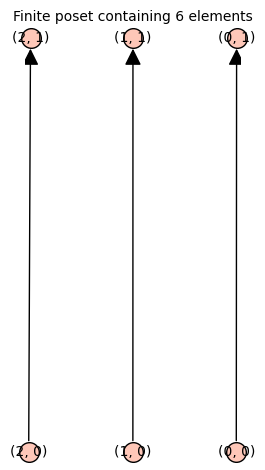

In [7]:
# Test two chain poset generation

n = 3
P = disjoint_two_chains(n)
P

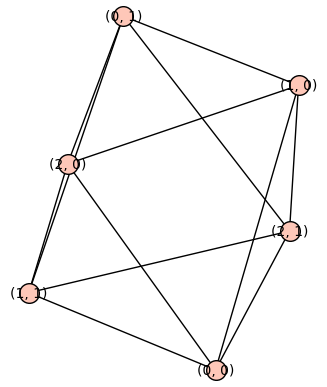

In [8]:
# Examine incomparability graph of test poset

G = P.incomparability_graph()
G.show()

In [11]:
# Test counting non-increasing paths of two chain posets


for i in range(1,6):
    P = disjoint_two_chains(i)
    sequence_count = N_sp_from_poset(P)
    print(f"Number of non-increasing sequences for K_(2^{i}) is {sequence_count}\n\n")   

Number of non-increasing sequences for K_(2^1) is 1


Number of non-increasing sequences for K_(2^2) is 14


Number of non-increasing sequences for K_(2^3) is 426


Number of non-increasing sequences for K_(2^4) is 24024


Number of non-increasing sequences for K_(2^5) is 2170680




In [14]:
# Test counting non-increasing paths of two chain posets  using combinatorial formmula


for i in range(1,6):
    sequence_count = N_sp_two_chains_poset_formula(i)
    print(f"Number of non-increasing sequences for K_(2^{i}) is {sequence_count}\n\n")   

Number of non-increasing sequences for K_(2^1) is 1


Number of non-increasing sequences for K_(2^2) is 14


Number of non-increasing sequences for K_(2^3) is 426


Number of non-increasing sequences for K_(2^4) is 24024


Number of non-increasing sequences for K_(2^5) is 2170680


